#  Superstore Sales Analysis
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** US Superstore Retail Transactions (2014–2017)  
**Goal:** Perform end-to-end EDA to uncover sales patterns, profit drivers, and business insights from 9,994 transactions.

---

##  Step 1: Import Libraries
We import all necessary libraries for data manipulation and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Step 2: Load Dataset
We load the Superstore CSV file into a Pandas DataFrame and take a first look at the data.

In [3]:
df=pd.read_csv('Superstore.csv')

In [4]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


##  Step 3: Data Quality Checks
Before any analysis, we check for:
- **Null values** — missing data that needs to be handled
- **Duplicates** — repeated rows that could skew results
- **Data types** — ensuring columns are in the correct format

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

##  Step 4: Convert Date Columns to DateTime
`Order Date` and `Ship Date` are stored as strings. We convert them to proper `datetime` format so we can perform time-based operations.

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

##  Step 5: Feature Engineering — Shipping Days
We create a new column `Shipping Days` by calculating the difference between `Ship Date` and `Order Date`.  
This tells us how long each order took to be delivered — useful for logistics analysis.

In [9]:
df['Shipping Days']=(df["Ship Date"]-df['Order Date']).dt.days

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [11]:
df["Order Date"].dt.year
df["Order Date"].dt.month
df["Order Date"].dt.day
df['Shipping Days']=(df['Ship Date']-df['Order Date']).dt.days
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


##  Step 6: Save Cleaned Data
We save the cleaned and feature-engineered dataset as a new CSV file for future use.

In [12]:
### save the cleaned data to a new CSV file
df.to_csv('Superstore_Cleaned.csv', index=False)
print("Cleaned data saved to Superstore_Cleaned.csv")

Cleaned data saved to Superstore_Cleaned.csv


---
##  Exploratory Data Analysis (EDA)
Now that the data is clean, we explore key patterns and relationships to extract business insights.

###  Descriptive Statistics
A quick statistical summary of all numerical columns.

In [13]:
df[['Sales','Profit','Discount','Quantity','Shipping Days']].describe()

,Sales,Profit,Discount,Quantity,Shipping Days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574,3.958175
std,623.245101,234.260108,0.206452,2.225110,1.747567
min,0.444000,-6599.978000,0.000000,1.000000,0.000000
25%,17.280000,1.728750,0.000000,2.000000,3.000000
50%,54.490000,8.666500,0.200000,3.000000,4.000000
75%,209.940000,29.364000,0.200000,5.000000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000,7.000000


---
###  Sales Distribution (Histogram)
How are sales values distributed across all transactions?

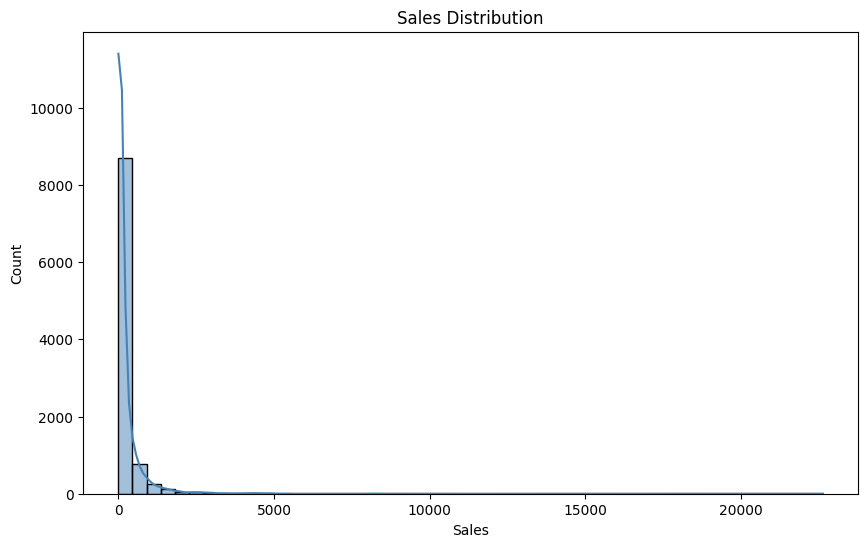

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sales'],bins=50,kde=True,color='steelblue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.show()

** Key Finding:** Sales distribution is **right-skewed** — most transactions are small-value orders, but a few very large orders pull the average up significantly.  
This suggests the presence of bulk or enterprise buyers.

###  Sales Boxplot — Outlier Detection
A boxplot reveals the spread of sales and highlights extreme outliers.

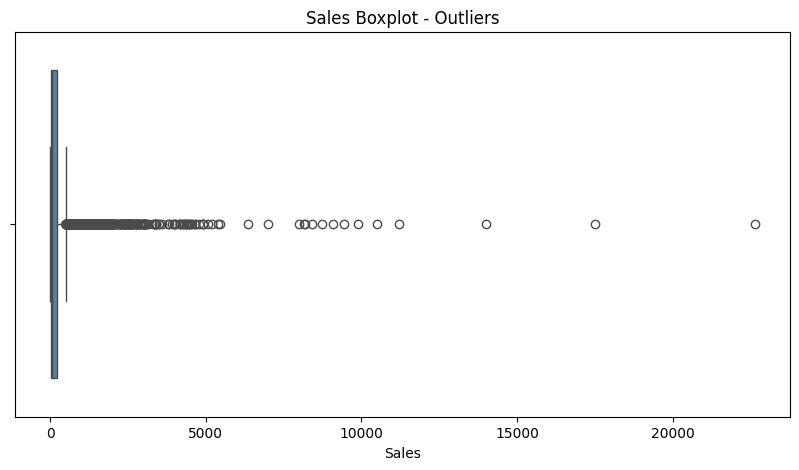

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Sales'],color='steelblue')
plt.title('Sales Boxplot - Outliers')
plt.show()

Key Finding: There are significant **outliers** in sales — some transactions are many times larger than the typical order.  
These high-value outliers can skew averages and need special attention in business reporting.

###  Profit Distribution (Histogram)
How is profit distributed? Are there losses (negative profit)?

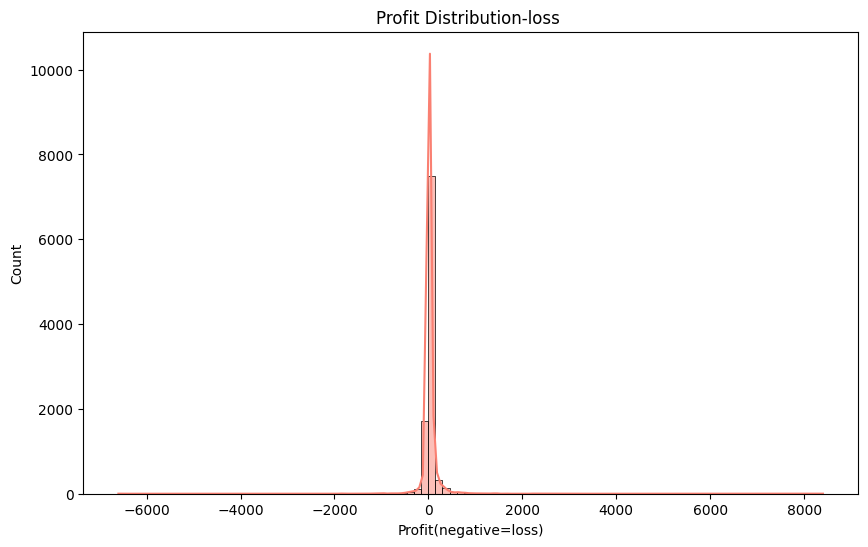

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['Profit'],bins=100,kde=True,color='salmon')
plt.title('Profit Distribution-loss ')
plt.xlabel('Profit(negative=loss)')
plt.ylabel('Count')
plt.show()

Key Finding: The profit distribution shows both **positive profits and losses** (negative values).  
A significant number of transactions result in losses — identifying these is critical for business health.

###  Discount vs Profit (Scatter Plot)
Does offering higher discounts lead to more losses?

C:\Users\Dell\AppData\Local\Temp\ipykernel_15028\3887420625.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


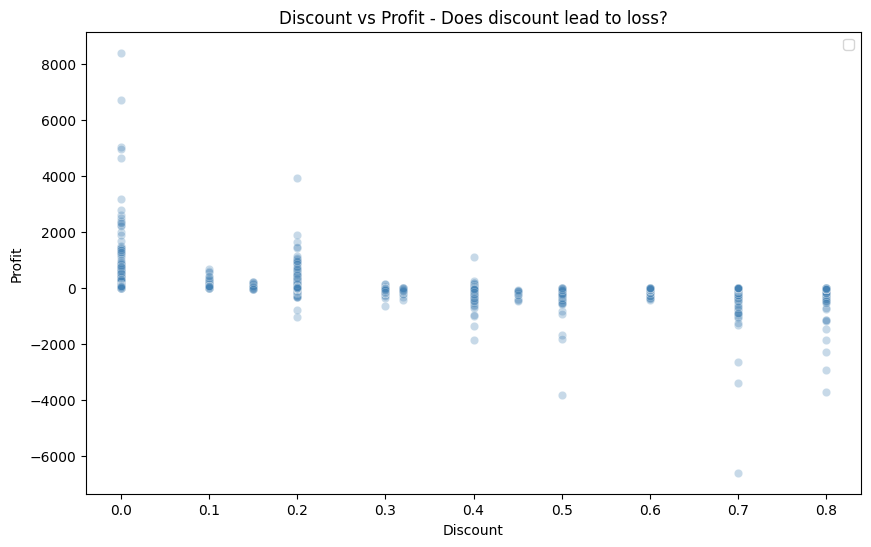

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Discount'],y=df['Profit'],alpha=0.3,color='steelblue')
plt.title('Discount vs Profit - Does discount lead to loss?')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend()
plt.show()

Key Finding: There is a **clear negative relationship** between discount and profit.  
Transactions with discounts **above 30–40%** consistently result in **negative profit margins** — meaning the business is losing money on heavily discounted items.  
This is one of the most important business insights from this analysis.

###  Total Sales by Category
Which product category generates the most revenue?

C:\Users\Dell\AppData\Local\Temp\ipykernel_15028\1417648284.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='Set2')
C:\Users\Dell\AppData\Local\Temp\ipykernel_15028\1417648284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='Set2')


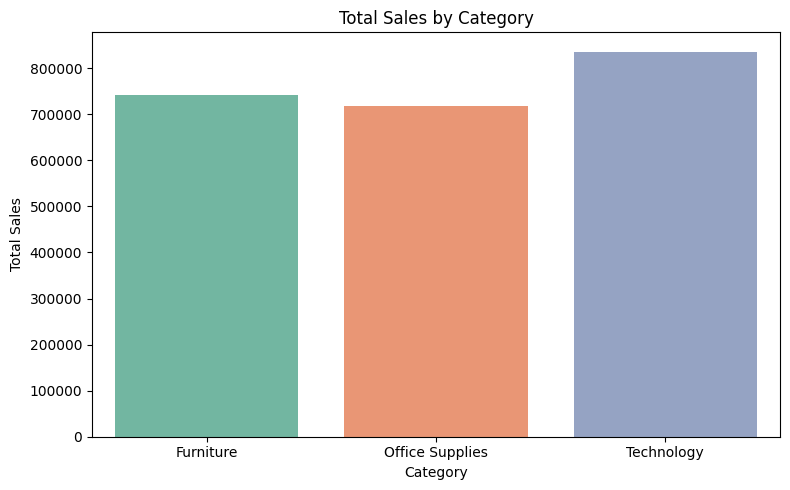

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='Set2')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

## Key Finding - Sales by Category
- Technology has the highest total sales (~$830K), followed by Furniture (~$740K)
- Office Supplies has the lowest sales but may have better profit margins

### Top 10 States by Profit
Which US states are the most profitable for the business?

C:\Users\Dell\AppData\Local\Temp\ipykernel_15028\3236497628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette='RdYlGn')


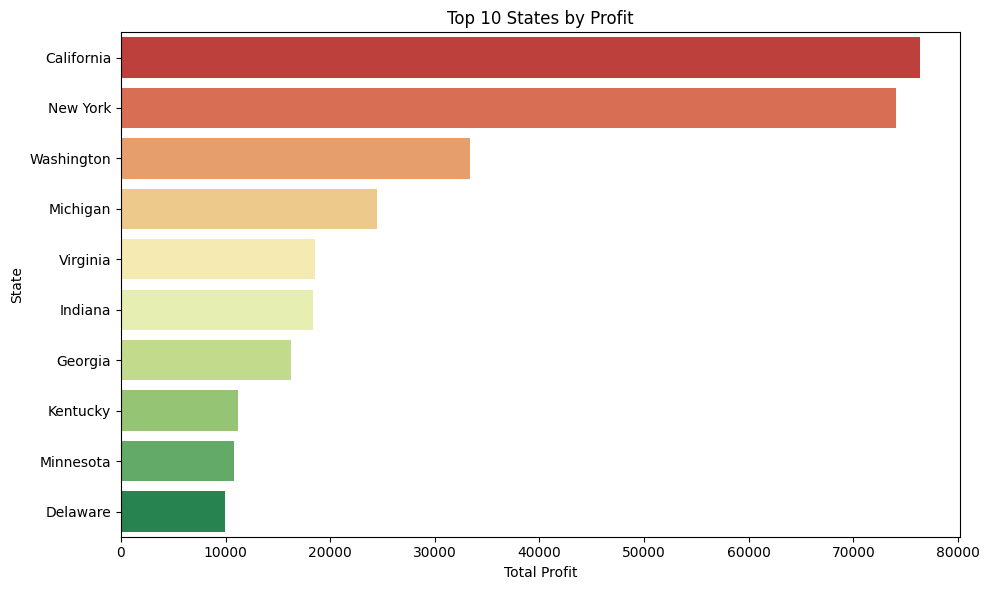

In [19]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=state_profit.values, y=state_profit.index, palette='RdYlGn')
plt.title('Top 10 States by Profit')
plt.xlabel('Total Profit')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Key Finding - Top States by Profit
- California and New York are the top 2 most profitable states (~$76K and ~$74K)
- Significant gap exists between top 2 and remaining states
- Business should focus marketing efforts on these high-performing regions

###  Monthly Sales Trend (2014–2017)
How have monthly sales changed over 4 years?

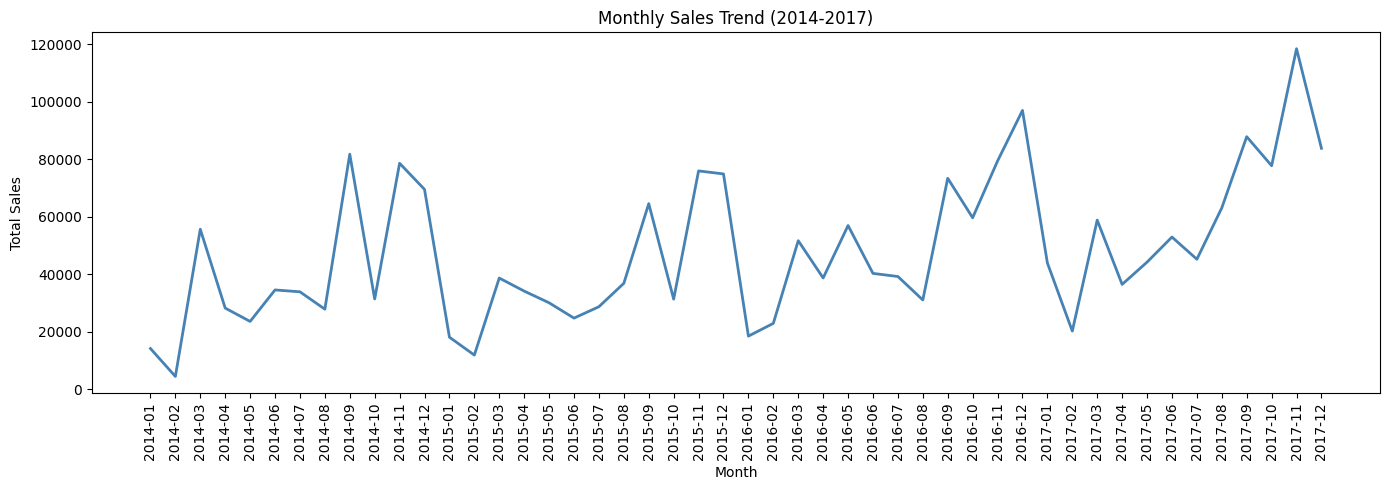

In [20]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(x='Month', y='Sales', data=monthly_sales, color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend (2014-2017)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Key Finding - Monthly Sales Trend
- Sales show consistent year-over-year growth from 2014 to 2017
- Peak sales occur in November each year (holiday season effect)
- January consistently shows the lowest sales (post-holiday slump)

---
##  Project Summary

| Detail | Info |
|--------|------|
| **Dataset** | US Superstore Retail Transactions |
| **Total Records** | 9,994 rows |
| **Time Period** | 2014 – 2017 |
| **Tools Used** | Python, Pandas, NumPy, Matplotlib, Seaborn |

### ✅ Key Insights:
1. **Technology** is the highest-revenue category (~$830K total sales)
2. **California** and **New York** are the most profitable states (~$76K and ~$74K)
3. Discounts **above 30%** consistently lead to **negative profit margins** — a major business risk
4. Sales show **year-over-year growth** with consistent **November peaks** (holiday season effect)
5. Sales distribution is **right-skewed** with significant high-value outliers

### 🛠️ Skills Demonstrated:
- Data Loading & Inspection
- Data Cleaning (null check, duplicate check, dtype fix)
- Feature Engineering (Shipping Days, Month extraction)
- Exploratory Data Analysis (EDA)
- Data Visualization (Matplotlib + Seaborn)
- Business Insight Extraction

---
**Author:** Waleed Ahmad | BS Data Science (2nd semester)— Riphah International University  
**GitHub:** [mianwaleed155847-hub](https://github.com/mianwaleed155847-hub)